## Wilks' theorem validity check

under H0 (f_s = 0) the true parameter sits on the boundary, so q is a 50/50 mixture of point mass at zero and chi2(1) rather than pure chi2(1). check directly with background-only toys.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from scipy.optimize import minimize
from scipy.stats import norm, chi2

os.makedirs("plots", exist_ok=True)

In [2]:
with open("fit_params.json") as fh:
    fit_params = json.load(fh)
with open("bdt_results.json") as fh:
    bdt_results = json.load(fh)

lam_fit = fit_params["lam_bkg"]
sig_eff = bdt_results["signal_efficiency"]
bkg_eff = bdt_results["background_efficiency"]

MASS_LO, MASS_HI = 4.0, 6.0
MU_SIG, SIG_SIG = 5.0, 0.03
N_BKG_YEAR = 2000 * bkg_eff

In [3]:
def exp_pdf(m, lam):
    return np.exp(-lam * m) / ((np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI)) / lam)


def composite_pdf(m, fs, lam):
    return fs * norm.pdf(m, MU_SIG, SIG_SIG) + (1 - fs) * exp_pdf(m, lam)


def sample_exp(lam, n, rng):
    u = rng.uniform(0, 1, size=n)
    return -np.log(np.exp(-lam * MASS_LO) - u * (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI))) / lam


def generate_toy(n_sig_mean, n_bkg_mean, lam, rng):
    masses = np.concatenate([rng.normal(MU_SIG, SIG_SIG, rng.poisson(n_sig_mean)),
                             sample_exp(lam, rng.poisson(n_bkg_mean), rng)])
    return masses[(masses >= MASS_LO) & (masses <= MASS_HI)]


def nll_composite(params, masses):
    fs, lam = params
    if fs < 0 or fs > 1 or lam <= 0:
        return 1e10
    v = composite_pdf(masses, fs, lam)
    return -np.sum(np.log(v)) if np.all(v > 0) else 1e10


def nll_bkg_only(params, masses):
    lam = params[0]
    return -np.sum(np.log(exp_pdf(masses, lam))) if lam > 0 else 1e10


def fit_toy(masses):
    r = minimize(nll_composite, x0=[0.02, lam_fit], args=(masses,), method="Nelder-Mead",
                 options={"xatol": 1e-5, "fatol": 1e-5, "maxiter": 5000})
    return float(r.fun)


def fit_bkg_only(masses):
    r = minimize(nll_bkg_only, x0=[lam_fit], args=(masses,), method="Nelder-Mead")
    return float(r.fun)

In [4]:
rng = np.random.default_rng(99)
N_TOYS_H0 = 500
toys_h0 = [generate_toy(0.0, N_BKG_YEAR, lam_fit, rng) for _ in range(N_TOYS_H0)]

q_h0 = np.array([max(0.0, 2 * (fit_bkg_only(t) - fit_toy(t))) for t in toys_h0])
print(f"frac(q=0) = {(q_h0 == 0).mean():.3f}   (expect ~0.5 from boundary)")
print(f"mean q    = {q_h0.mean():.3f}")

frac(q=0) = 0.130   (expect ~0.5 from boundary)
mean q    = 0.439


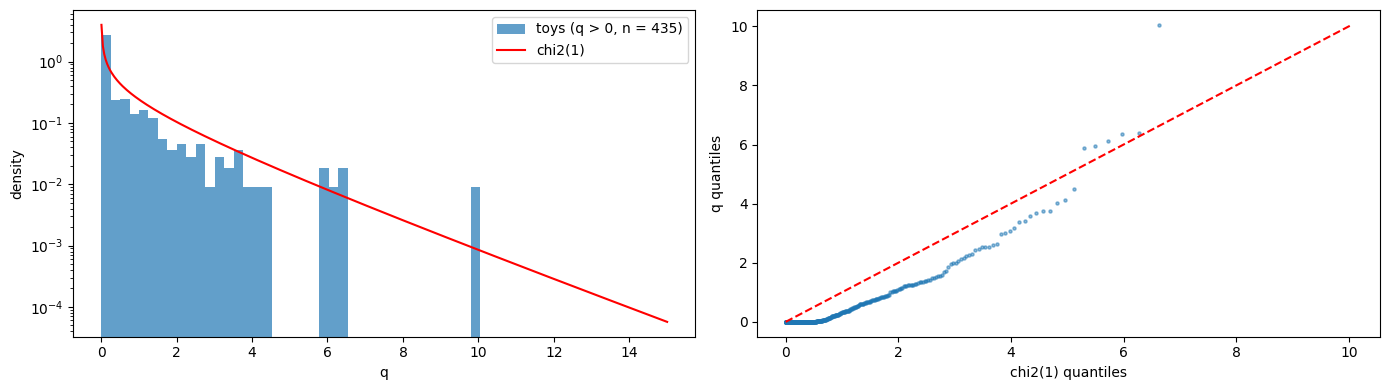

P(q > 1^2): observed = 0.146, chi2(1) = 0.317
P(q > 2^2): observed = 0.018, chi2(1) = 0.046
P(q > 3^2): observed = 0.002, chi2(1) = 0.003


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
q_range = np.linspace(0.01, 15, 400)
ax.hist(q_h0[q_h0 > 0], bins=40, density=True, alpha=0.7, label=f"toys (q > 0, n = {int((q_h0 > 0).sum())})")
ax.plot(q_range, chi2.pdf(q_range, df=1), color="red", label="chi2(1)")
ax.set_xlabel("q"); ax.set_ylabel("density"); ax.set_yscale("log"); ax.legend()

ax = axes[1]
qs = np.sort(q_h0[q_h0 > 0])
th = chi2.ppf(np.linspace(0.01, 0.99, len(qs)), df=1)
ax.scatter(th, qs, s=5, alpha=0.5)
lim = max(th.max(), qs.max())
ax.plot([0, lim], [0, lim], color="red", linestyle="--")
ax.set_xlabel("chi2(1) quantiles"); ax.set_ylabel("q quantiles")

plt.tight_layout()
plt.savefig("plots/wilks_validity.png", dpi=150, bbox_inches="tight")
plt.show()

for z in [1, 2, 3]:
    obs = (q_h0 > z ** 2).mean()
    exp = chi2.sf(z ** 2, df=1)
    print(f"P(q > {z}^2): observed = {obs:.3f}, chi2(1) = {exp:.3f}")